# Data Sourcing

## Finding Data

📃 I can export it from an application (**CSV**)

🗄️ I know it exists somewhere in a database (**SQL**)

🌐 It's on this website I visit daily (**Scraping**)

{ } I have found a service (**API**) that gives access to it

...

## Plan

1. 📃 Reading CSVs
2. { } Consuming an API
3. 🌐 Scraping a website
4. 💾 Saving our collected data
5. 📊 Analysing the data
6. 🎯 We will load and enrich a 🐼 DataFrame with data from different sources 🚀

## 🎯 Our mission

We want to visualize CO<sub>2</sub> emissions by continent.

We will combine data from 3 sources:

**1. CSV Data with CO<sub>2</sub> emissions per capita by country from [Gapminder](https://www.gapminder.org/about/)**

<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/02-Data-Toolkit/02-Data-Sourcing/logo-gapminder.svg" alt="Gapminder logo" width="100" height="20"></center>


**2. Population data from the  [World Bank Open Data](https://data.worldbank.org/) API**

<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/02-Data-Toolkit/02-Data-Sourcing/logo-worldbank.svg" alt="World Bank Group logo" width="100" height="20"></center>


**3. Geographical Data from the [Wikipedia](https://en.wikipedia.org/wiki/Wikipedia) website**

<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/02-Data-Toolkit/02-Data-Sourcing/logo-wikipedia.png" alt="Wikipedia logo" width="70" height="90"></center>


## 📃 CSV¶

> A **comma-separated values** file is a delimited text file that uses a comma to separate values. <br><br>
A CSV file stores **tabular data** (numbers and text) in plain text. <br><br>
Each line of the file is a data **record**. <br><br>
Each record consists of one or more **fields**, separated by commas.


Source: [Wikipedia](https://kitt.lewagon.com/camps/2007/lectures/content/02-Data-Toolkit_02-Data-Sourcing-new.html#:~:text=Source%3A-,Wikipedia,-CO2%20emissions)

### CO<sub>2</sub> emissions

👉 Head to the [Gapminder data website](https://kitt.lewagon.com/camps/2007/lectures/content/02-Data-Toolkit_02-Data-Sourcing-new.html#:~:text=Gapminder%20data%20website) and search for the CO<sub>2</sub> *emissions per capita* data and download it as a `csv` into the `data` folder.

Let's first have a look at a sample file.

In [10]:
%%bash
mkdir -p data
curl -s https://wagon-public-datasets.s3.amazonaws.com/02-Data-Toolkit/02-Data-Sourcing/co2_sample.csv > data/co2_sample.csv
head -n 5 data/co2_sample.csv

country,2014,2015,2016,2017,2018,2019,2020,2021,2022
Afghanistan,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284
Angola,1.64,1.22,1.18,1.15,1.12,1.15,1.12,1.2,1.23
Albania,2.25,2.04,2.01,2.13,2.08,2.05,2.0,2.12,2.1
Andorra,5.83,5.97,6.07,6.27,6.12,6.06,5.63,5.97,5.91


In [11]:
!pwd

/Users/davywai/code/lewagon/wgn-ds-2025/W01D04__DataSourcingPandas


In [13]:
!tree -L 2

.
├── 02-Data-Toolkit_02_Data-Sourcing-1-Lecture.ipynb
└── data
    └── co2_sample.csv

2 directories, 2 files


Our real dataset will contain all countries, and many more years of data.

### CSV Reading in Python

**The hard way**

Use the [csv module](https://docs.python.org/3/library/csv.html) of the 🐍 Python Standard Library.

**But we already know better!**

**The easy way**

Use 🐼 Pandas!

### Back to our 🎯mission

In [15]:
import pandas as pd
import pandas as pd
emissions_df = pd.read_csv('data/co2_sample.csv')
emissions_df

,country,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Afghanistan,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284
1,Angola,1.640,1.220,1.180,1.150,1.120,1.150,1.120,1.200,1.230
2,Albania,2.250,2.040,2.010,2.130,2.080,2.050,2.000,2.120,2.100
3,Andorra,5.830,5.970,6.070,6.270,6.120,6.060,5.630,5.970,5.910
4,UAE,26.800,27.000,26.700,23.900,23.500,21.200,19.700,20.700,21.100
5,Argentina,4.300,4.600,4.270,4.310,3.950,3.720,3.520,3.770,3.850
6,Armenia,2.000,2.030,1.920,2.020,2.490,2.450,2.570,2.730,2.700
7,Antigua and Barbuda,5.710,5.840,5.900,5.890,5.880,5.860,5.440,5.820,5.940
8,Australia,16.200,16.000,15.300,15.300,14.600,14.200,13.700,13.700,13.900
9,Austria,11.100,10.300,10.600,10.400,10.300,10.000,9.070,9.290,9.200


### CSVs can have different formats

* Separated by different characters: `,`, `;`, `|`, `\t`
* With or without a header row
* With or without an index column
* Date and time formats (e.g. `DD/MM/YYYY`, `MM-DD-YYYY`)

[`pandas.read_csv`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) has many parameters that will let you deal with that.

Your output doesn't look right?

Read the [documentation of pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)  before you try to reinvent the wheel!

### Can we improve our DataFrame?

The country is a name for now.

That's not very universal:
* Names could be in another language.
* Line 4 is named `UAE`. What if someone wrote it in full?

Let's add ISO 2-digit country codes and full names. We'll need both in the next parts.

In [16]:
!curl -s https://wagon-public-datasets.s3.amazonaws.com/02-Data-Toolkit/02-Data-Sourcing/iso_codes.csv > data/iso_codes.csv
iso_df = pd.read_csv('data/iso_codes.csv', na_filter=False)
iso_df.head()

,Name,Code,Full Name
0,Afghanistan,AF,Afghanistan
1,Åland Islands,AX,Åland Islands
2,Albania,AL,Albania
3,Algeria,DZ,Algeria
4,American Samoa,AS,American Samoa


Why `na_filter = False`?

The country code for Namibia is "NA", by default this is interpreted as *`NaN`* (*Not a Number*).

Let's merge our two DataFrames.

In [17]:
emissions_df = emissions_df.merge(iso_df, left_on='country', right_on='Name')
emissions_df = emissions_df.drop(columns=['country'])
emissions_df

,2014,2015,2016,2017,2018,2019,2020,2021,2022,Name,Code,Full Name
0,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284,Afghanistan,AF,Afghanistan
1,1.640,1.220,1.180,1.150,1.120,1.150,1.120,1.200,1.230,Angola,AO,Angola
2,2.250,2.040,2.010,2.130,2.080,2.050,2.000,2.120,2.100,Albania,AL,Albania
3,5.830,5.970,6.070,6.270,6.120,6.060,5.630,5.970,5.910,Andorra,AD,Andorra
4,26.800,27.000,26.700,23.900,23.500,21.200,19.700,20.700,21.100,UAE,AE,UAE
5,4.300,4.600,4.270,4.310,3.950,3.720,3.520,3.770,3.850,Argentina,AR,Argentina
6,2.000,2.030,1.920,2.020,2.490,2.450,2.570,2.730,2.700,Armenia,AM,Armenia
7,5.710,5.840,5.900,5.890,5.880,5.860,5.440,5.820,5.940,Antigua and Barbuda,AG,Antigua and Barbuda
8,16.200,16.000,15.300,15.300,14.600,14.200,13.700,13.700,13.900,Australia,AU,Australia
9,11.100,10.300,10.600,10.400,10.300,10.000,9.070,9.290,9.200,Austria,AT,Austria


## <h2 style="color:blue">{ } API</h2>

> An **application programming interface** (API) is an interface or **communication protocol** between a client and a server intended to simplify the building of client-side software. <br> <br> It has been described as a **“contract”** between the client and the server.

Source: [Wikipedia](https://en.wikipedia.org/wiki/Application_programming_interface)

### An example

Github's [interface for humans](https://github.com/ssaunier) *vs.* their [API](https://api.github.com/users/ssaunier)

👉 [Many more examples](https://github.com/public-apis/public-apis)

### HTTP

A client-server protocal based on a **request/response** cycle.

<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/data-engineering/web101.png" alt="Web 101" width="600" height="300"></center>

### HTTP Request

<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/data-engineering/http_request_02.png" alt="HTTP Request" width="600" height="300"></center>

### HTTP Response

<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/data-engineering/http_response_02.png" alt="HTTP Response" width="600" height="300"></center>

### Modern Web APIs:
* Are RESTful (`GET`, `POST`, etc...)
* Return [`JSON`](https://en.wikipedia.org/wiki/JSON#JSON_sample)

### Requests: HTTP for Humans<sup>TM</sup>

👉 [Documentation](https://requests.readthedocs.io/)

#### Basic request

In [ ]:
import requests

url = 'https://api.github.com/users/ssaunier'
response = requests.get(url).json()
response

{'login': 'ssaunier',
 'id': 414418,
 'node_id': 'MDQ6VXNlcjQxNDQxOA==',
 'avatar_url': 'https://avatars.githubusercontent.com/u/414418?v=4',
 'gravatar_id': '',
 'url': 'https://api.github.com/users/ssaunier',
 'html_url': 'https://github.com/ssaunier',
 'followers_url': 'https://api.github.com/users/ssaunier/followers',
 'following_url': 'https://api.github.com/users/ssaunier/following{/other_user}',
 'gists_url': 'https://api.github.com/users/ssaunier/gists{/gist_id}',
 'starred_url': 'https://api.github.com/users/ssaunier/starred{/owner}{/repo}',
 'subscriptions_url': 'https://api.github.com/users/ssaunier/subscriptions',
 'organizations_url': 'https://api.github.com/users/ssaunier/orgs',
 'repos_url': 'https://api.github.com/users/ssaunier/repos',
 'events_url': 'https://api.github.com/users/ssaunier/events{/privacy}',
 'received_events_url': 'https://api.github.com/users/ssaunier/received_events',
 'type': 'User',
 'user_view_type': 'public',
 'site_admin': False,
 'name': 'Sébas

In [20]:
response["name"]

'Sébastien Saunier'

#### Back to our 🎯 mission

Let's use the [World Bank Open Data](https://data.worldbank.org/) API

This API documentation is not *that* good - let's decipher it together.

**Our goal**: find the population for ou country in 2022

**Query parameters**:
* Provide an ISO2 country code inside the URL (`country/BE/`)
* Key value pairs:
    * `format=json`
    * `year=2022`

**With Python and the Requests library**

In [21]:
import requests

In [22]:
country = "CN"
year = 2023

In [27]:
url = f"https://api.worldbank.org/v2/country/{country}/indicator/SP.POP.TOTL"

params = {
    'format': 'json',
    'date': year
}

response = requests.get(url=url, params=params)

result = response.json()
result[1][0]["value"]

1410710000

Let's refactor this into a reusable function, and add a bit of error catching:

In [28]:
def fetch_population(country, year):
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/SP.POP.TOTL"

    params = {
        'format': 'json',
        'date': year
    }

    response = requests.get(url=url, params=params)

    if response.status_code != 200:
        print(f"Error for {country} - {year}: status code {response.status_code} ")
        return None

    result = response.json()

    if len(result) == 1 or not result[1]:
        print(f"Error for {country} - {year}: {result}")
        return None

    return result[1][0]['value']

In [31]:
fetch_population('FR', 2023)

68287487

🙈 OK, back to our Dataframe `emissions_df`.

Let's use this `fetch_population` function to loop over each row of the DataFrame and create a new column:

💡 Let's use [`pandas.DataFrame.iterrows`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html) and [`pandas.DataFrame.loc`](https://kitt.lewagon.com/camps/2007/lectures/content/02-Data-Toolkit_02-Data-Sourcing-new.html#:~:text=pandas.DataFrame.loc)

In [32]:
%%time
for index, row in emissions_df.head(3).iterrows():
    print(f"Fetching population for {row['Name']} - {row['Code']}")
    population = fetch_population(row['Code'], 2022)
    emissions_df.loc[index, 'Population'] = population

Fetching population for Afghanistan - AF
Fetching population for Angola - AO
Fetching population for Albania - AL
CPU times: user 10.5 ms, sys: 4.07 ms, total: 14.6 ms
Wall time: 849 ms


In [33]:
emissions_df.head()

,2014,2015,2016,2017,2018,2019,2020,2021,2022,Name,Code,Full Name,Population
0,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284,Afghanistan,AF,Afghanistan,40578842.0
1,1.640,1.220,1.180,1.150,1.120,1.150,1.120,1.200,1.230,Angola,AO,Angola,35635029.0
2,2.250,2.040,2.010,2.130,2.080,2.050,2.000,2.120,2.100,Albania,AL,Albania,2777689.0
3,5.830,5.970,6.070,6.270,6.120,6.060,5.630,5.970,5.910,Andorra,AD,Andorra,NaN
4,26.800,27.000,26.700,23.900,23.500,21.200,19.700,20.700,21.100,UAE,AE,UAE,NaN


We're good to proceed with our whole DataFrame.

In [34]:
%%time
# Fetch population for all countries in the emissions_df
# This will take a while, as we are making a lot of requests
for index, row in emissions_df.iterrows():
    print(f"Fetching population for {row['Name']} - {row['Code']}")
    population = fetch_population(row['Code'], 2022)
    emissions_df.loc[index, 'Population'] = population

Fetching population for Afghanistan - AF
Fetching population for Angola - AO
Fetching population for Albania - AL
Fetching population for Andorra - AD
Fetching population for UAE - AE
Fetching population for Argentina - AR
Fetching population for Armenia - AM
Fetching population for Antigua and Barbuda - AG
Fetching population for Australia - AU
Fetching population for Austria - AT
CPU times: user 61.9 ms, sys: 13.7 ms, total: 75.6 ms
Wall time: 7.38 s


That took ages! Can we do better?
Yes, the API actually allows us to ask the data for all countries in bulk.

That's almost always a better option:

* the response will be longer and more complex,
* but we'll only have to make one request!

🤯 Have a look at the appendix for an example that fetches the same data in a few seconds.

## 🌐 Webscraping

## HTTP (again)

This time, we'll have to deal with **HTML** (~unstructured data)

#### HTTP website example

<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/01-Python/html_diagram.png" alt="HMTL diagram" width="600" height="200"></center>

#### What does that HTML look like?

* Right click -> **Inspect Element** on any website
* Typically has a tree-like structure like in this [example](https://wagon-public-datasets.s3.amazonaws.com/02-Data-Toolkit/02-Data-Sourcing/example.html)

<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/02-Data-Toolkit/02-Data-Sourcing/html-example.png" alt="HMTL example" width="600" height="300"></center>

#### HTML Vocabulary

<center><img src="https://4.bp.blogspot.com/-B5vUzJXNAoE/Vuay2ygsN2I/AAAAAAAAG5o/-qOAVBa3LRkJ0fPWywYzkAcmezRAY2Rxg/s640/html-syntax.png" alt="HMTL syntax" width="500" height="200"></center>

### Beautiful Soup

**The** python package to browse HTML (and XML!)

👉 [Documentation](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)

#### Typical Web Scraper with `BeautifulSoup`

```python
import requests
from bs4 import BeautifulSoup

response = requests.get(url)
soup = BeautifulSoup(response.content, "html.parser")

# You now can query the `soup` object!
soup.title.string
soup.find('h1')
soup.find_all('a')
# etc...
```

#### Searching by element name

```html
<h1>My First Heading</h1>
<p>This is a very simple html page.</p>
<h1>Content</h1>
<h2>Articles</h2>
<article>How to load CSVs?</article>
<article>API calls with Python</article>
<article>Scraping with BeautifulSoup</article>
```

```python
paragraph = soup.find("p")
articles = soup.find_all("article")
```

#### Searching by CSS Class

```html
<h2>Packages we use today</h2>
<ul>
  <li class="built-in">CSV</li>
  <li class="package">Pandas</li>
  <li class="package">Requests</li>
  <li class="package">BeautifulSoup</li>
</ul>
```

```python
items = soup.find_all("li", class_="package")
```

Mind the use of `class_` instead of `class`!

#### Searching by id

```html
<div id="credits">
  <span>Made with ❤️ in Paris.</p>
  <span>By <a href="http://www.lewagon.com" id="author">Le Wagon</a>.</p>
</div>
```

```python
item = soup.find(id="author").text
```

### Back to our 🎯mission

Let's scrape [Wikipedia](https://data.worldbank.org/) to enrich our data even further.

**Our goal**: find the continent of our country.

We can find the continent via this url:

`https://en.wikipedia.org/wiki/Geography_of_<Country_name>`

For example: [https://en.wikipedia.org/wiki/Geography_of_Belgium](https://en.wikipedia.org/wiki/Geography_of_Belgium)

The continent is the first element of the `infobox`.

Use your browser's inspect function to see how you could extract the data.

#### With Python and the `Request` and `BeautifulSoup` libraries

In [35]:
import requests
from bs4 import BeautifulSoup

When you start scraping, get it working for one row first.

Then refactor it to get all the data.

In [36]:
# What does our URL look like?
url = "https://en.wikipedia.org/wiki/Geography_of_Belgium"
# Get the response
response = requests.get(url)
# Turn it into Soup
soup = BeautifulSoup(response.text, "html.parser")
# Find the infobox
infobox = soup.find(class_="infobox-data")
# Extract the continent
continent = infobox.text
print(continent)

Europe


Now, let's chain this together into a function.

In [ ]:
def continent_scraper(country):
    url = f"https://en.wikipedia.org/wiki/Geography_of_{country}"
    print(f"Scraping info for {country}")
    try:
        # Get the response
        response = requests.get(url)
        # Turn it into Soup
        soup = BeautifulSoup(response.text, "html.parser")
        # Find the infobox
        infobox = soup.find(class_="infobox-data")
        # Extract the continent
        continent = ainfobox.text
        return continent
    except:
        return None

In [38]:
continent_scraper("Belgium")

Scraping info for Belgium


'Europe'

A word on the `try ... except ...` construction:

* This is the Pythonic way to catch errors, you will see it regularly in production code.
* Here we use it to handle not finding the country or its continent.
* **Don't add a `try ... except ...` construction while you're still developing!**
* It catches all errors ... so **you will never see any error message**, and you won't know what is wrong with your code.
* Only add `try ... except ...` when you already know that your code works.

We can now get all continents with a for loop:

In [ ]:
countries_list = list(emissions_df['Full Name'])

continents = []
for country in countries_list:
    continent = continent_scraper(country)
    continents.append(continent)

Scraping info for Afghanistan
Scraping info for Angola
Scraping info for Albania
Scraping info for Andorra
Scraping info for UAE
Scraping info for Argentina
Scraping info for Armenia
Scraping info for Antigua and Barbuda
Scraping info for Australia
Scraping info for Austria


#### Merging the data

We could put our two lists into a DataFrame and merge with our `emissions_df`.

But let's use another method for this example.

Let's create a dictionary out of our two lists:
* First use Python's built-in [`zip`](https://docs.python.org/3/library/functions.html#zip) function to turn two lists into a list of tuples
* Then use `dict()` to turn the tuples into a dictionary.

In [41]:
letters = ['a', 'b']
numbers = [1, 2]
for element in zip(letters, numbers):
    print(element)

('a', 1)
('b', 2)


In [ ]:
dict(zip(letters, numbers))

{'a': 1, 'b': 2}

In [43]:
continents_dict = dict(zip(countries_list, continents))
continents_dict

{'Afghanistan': 'Asia',
 'Angola': 'Africa',
 'Albania': 'Europe',
 'Andorra': None,
 'UAE': None,
 'Argentina': 'South America',
 'Armenia': None,
 'Antigua and Barbuda': 'Caribbean',
 'Australia': 'Oceania (continent)',
 'Austria': None}

Now we can use [`pandas.DataFrame.map`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html) to map each country to its continent with this dictionary.

Let's try it out:

In [44]:
emissions_df['Full Name'].map(continents_dict).head()

0      Asia
1    Africa
2    Europe
3      None
4      None
Name: Full Name, dtype: object

Now that we know it works, we can assign the result to a new column in our DataFrame.

In [45]:
emissions_df['Continent'] = emissions_df['Full Name'].map(continents_dict)

#### Check the results

In [48]:
emissions_df["Continent"].isnull().sum()

4

Our scraping has missed quite a few continents 😥

Why?

* Example "St. Lucia": Wikipedia wants "Saint Lucia".
* Example Burkina Faso: doesn't have an `infobox`.
* Example Andorra or Austria: the infobox has a different format.

⚠️ Scraping can be unreliable and time-consuming.

So only use it as a last resort when there are no SQL databases, CSVs or APIs.

😇 For future reference - Wikipedia has a lovely [API for Python](https://wikipedia-api.readthedocs.io/en/latest/README.html).

🤓 In this case we could have very easily found a CSV with the continents.

#### 💾 Saving the data we collected

We went through all this effort to collect your data.

💡 It's good practice to **save your data** before you continue manipulating it.

🤓 This way you don't to wait again for the API calls or scraping to finish.

Also know that:
* API calls can come at a cost 💶
* Websites might 🚫 block you if you scrape them (too much)

💡 Pro tip in case you make lots of API calls or scrape loads of data:

* Save your intermediary results.
* Add some code to your loop that saves your results every X steps.

#### 🧹 Tidying up our DataFrame

Let's change the order of the columns:

In [50]:
emissions_df.head(2)

,2014,2015,2016,2017,2018,2019,2020,2021,2022,Name,Code,Full Name,Population,Continent
0,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284,Afghanistan,AF,Afghanistan,40578842.0,Asia
1,1.640,1.220,1.180,1.150,1.120,1.150,1.120,1.200,1.230,Angola,AO,Angola,35635029.0,Africa


In [ ]:
new_order = ['Code',
             'Name',
             'Full Name',
             'Continent',
             'Population']
new_order += list(emissions_df.columns)[:-5]
emissions_df = emissions_df[new_order]
emissions_df.head(2)

,Code,Name,Full Name,Continent,Population,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,AF,Afghanistan,Afghanistan,Asia,40578842.0,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284
1,AO,Angola,Angola,Africa,35635029.0,1.640,1.220,1.180,1.150,1.120,1.150,1.120,1.200,1.230


#### 💾 Saving to a csv file¶

Use [`pandas.DataFrame.to_csv`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html):


In [53]:
emissions_df.to_csv("data/emissions_enriched.csv", index=False)

In [55]:
!tree -L 2 data

data
├── co2_sample.csv
├── emissions_enriched.csv
└── iso_codes.csv

1 directory, 3 files


Quickly check the output:

In [56]:
!head -n 2 data/emissions_enriched.csv

Code,Name,Full Name,Continent,Population,2014,2015,2016,2017,2018,2019,2020,2021,2022
AF,Afghanistan,Afghanistan,Asia,40578842.0,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284


#### 💾 Other file formats

Pandas can handle many different file formats.

📚 Check the full list [here](https://pandas.pydata.org/docs/reference/io.html)

❗️ **CSV** is actually an **inefficient** format to save data.

It converts all data (even numbers) into text. That takes up much more space.

So if you have a large dataset, better look at **alternatives**.

🤯 A popular alternative is the very efficient binary [Apache Parquet](https://en.wikipedia.org/wiki/Apache_Parquet) format.

Using it in Pandas is as easy as using CSVs!

## 📊 Time to analyze the data!

Now that we have all the information, we can finally create our full DataFrame.

In [57]:
emissions_2022 = emissions_df[['Full Name', 'Continent', '2022', 'Population']].copy()
emissions_2022["Total Emissions"] = emissions_2022["2022"] * emissions_2022["Population"]
emissions_2022 = emissions_2022.rename(columns={'2022': 'Emissions Per Capita'})
emissions_2022.head()

,Full Name,Continent,Emissions Per Capita,Population,Total Emissions
0,Afghanistan,Asia,0.284,40578842.0,1.152439e+07
1,Angola,Africa,1.230,35635029.0,4.383109e+07
2,Albania,Europe,2.100,2777689.0,5.833147e+06
3,Andorra,None,5.910,79705.0,4.710565e+05
4,UAE,None,21.100,10074977.0,2.125820e+08


### Quick plots with pandas

Let's use [`pandas.DataFrame.hist`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html) and [`pandas.DataFrame.plot`]("https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html") to visualize some of the stats we've pulled together!

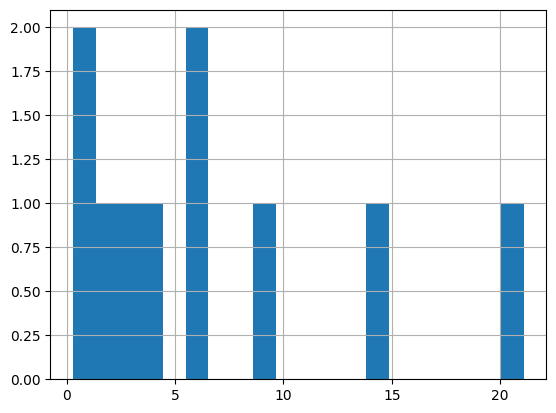

In [58]:
emissions_2022["Emissions Per Capita"].hist(bins=20);

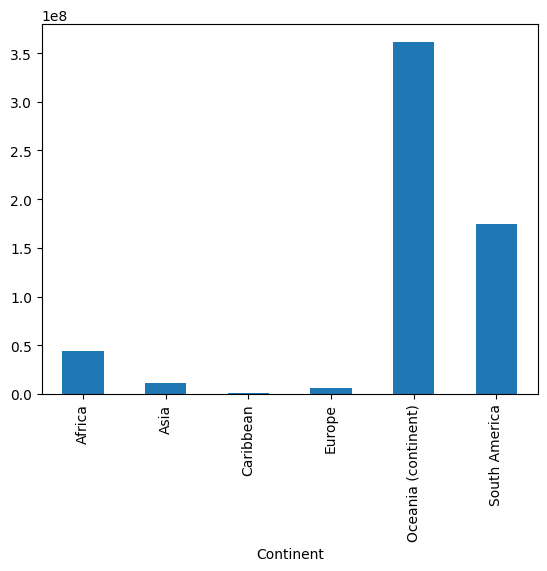

In [59]:
emissions_2022.groupby("Continent")["Total Emissions"].sum().plot(kind='bar');

## Your turn! 🚀

### Appendix

#### Querying a paginated API

Let's use the World Bank API to fetch the population for all countries in (almost) one go.

In [ ]:
# In the url we just replace "{country}" by "all"
url = f"https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL"

params = {
    'format': 'json',
    'date': year
}

response = requests.get(url=url, params=params).json()
print(f"We have {len(response[1])} countries in our result.")
response

We have 50 countries in our result.


[{'page': 1,
  'pages': 6,
  'per_page': 50,
  'total': 266,
  'sourceid': '2',
  'lastupdated': '2025-04-15'},
 [{'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'},
   'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
   'countryiso3code': 'AFE',
   'date': '2023',
   'value': 750503764,
   'unit': '',
   'obs_status': '',
   'decimal': 0},
  {'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'},
   'country': {'id': 'ZI', 'value': 'Africa Western and Central'},
   'countryiso3code': 'AFW',
   'date': '2023',
   'value': 509398589,
   'unit': '',
   'obs_status': '',
   'decimal': 0},
  {'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'},
   'country': {'id': '1A', 'value': 'Arab World'},
   'countryiso3code': 'ARB',
   'date': '2023',
   'value': 481667539,
   'unit': '',
   'obs_status': '',
   'decimal': 0},
  {'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'},
   'country': {'id': 'S3', 'value': 'Caribbean smal

The API is only returning 50 results. It's **paginated**, to avoid sending too much data at once.

🤯 We can query the 6 pages in a loop:

In [ ]:
# Create empty lists as placeholders for the codes, names and populations
country_codes = []
country_names = []
populations = []

# Start at page 1 and start a while loop (we don't know how many pages we'll get)
page = 1
while True:
    url = f"https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL"

    params = {
        'format': 'json',
        'date': year,
        'page': page   # This is new: we pass the page we want as a param
    }

    response = requests.get(url=url, params=params).json()

    # Add the codes, names and populations to our placeholders
    country_codes.extend([result['country']['id'] for result in response[1]])
    country_names.extend([result['country']['value'] for result in response[1]])
    populations.extend(result['value'] for result in response[1])

    # Check if this wasn't the last page
    if page == response[0]['pages']:
        break
    # Get ready for the next page
    page += 1

🏎️ How fast was that! 2 seconds instead of a full minute!

Now put the results in a DataFrame that we can merge into `emissions_df`:

In [ ]:
population_df = pd.DataFrame({
    'Code': country_codes,
    'Name': country_names,
    'Population': populations
})
population_df.sort_values('Name')

,Code,Name,Population
49,AF,Afghanistan,4.145476e+07
0,ZH,Africa Eastern and Southern,7.505038e+08
1,ZI,Africa Western and Central,5.093986e+08
50,AL,Albania,2.745972e+06
51,DZ,Algeria,4.616422e+07
...,...,...,...
262,PS,West Bank and Gaza,5.165775e+06
48,1W,World,8.061876e+09
263,YE,"Yemen, Rep.",3.939080e+07
264,ZM,Zambia,2.072396e+07


In [ ]:
population_df = pd.DataFrame({
    'Code': country_codes,
    'Name': country_names,
    'Population': populations
})
population_df.sort_values('Name')

,Code,Name,Population
49,AF,Afghanistan,4.145476e+07
0,ZH,Africa Eastern and Southern,7.505038e+08
1,ZI,Africa Western and Central,5.093986e+08
50,AL,Albania,2.745972e+06
51,DZ,Algeria,4.616422e+07
...,...,...,...
262,PS,West Bank and Gaza,5.165775e+06
48,1W,World,8.061876e+09
263,YE,"Yemen, Rep.",3.939080e+07
264,ZM,Zambia,2.072396e+07


#### Bonus

🤯 Don't want to type a request with many options by hand?

First use the browser's inspect function to get a `cURL` command:

<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/02-Data-Toolkit/02-Data-Sourcing/inspect_curl.png" alt="Inspect CURL" width="450" height="300"></center>

Then convert the cURL command to Python Requests using [this site](https://sqqihao.github.io/trillworks.html).